In [8]:
import torch

def generate_positions(N, box_size=5.0, min_dist=0.8):
    positions = []

    while len(positions) < N:
        candidate = torch.rand(3) * box_size

        if all(torch.norm(candidate - p) > min_dist for p in positions):
            positions.append(candidate)

    return torch.stack(positions)

In [9]:
def lennard_jones_energy(positions, epsilon=1.0, sigma=1.0, cutoff=None):
    N = positions.shape[0]
    E = 0.0

    for i in range(N):
        for j in range(i+1, N):
            r = torch.norm(positions[i] - positions[j])

            if cutoff is not None and r > cutoff:
                continue

            sr6 = (sigma / r)**6
            E += 4 * epsilon * (sr6**2 - sr6)

    return E

In [10]:
def compute_energy_and_forces(positions):
    positions = positions.clone().requires_grad_(True)

    energy = lennard_jones_energy(positions)
    energy.backward()

    forces = -positions.grad
    return energy.detach(), forces.detach()

In [11]:
def generate_dataset(num_samples, N):
    data = []

    for _ in range(num_samples):
        pos = generate_positions(N)
        energy, forces = compute_energy_and_forces(pos)

        data.append({
            "positions": pos,
            "energy": energy,
            "forces": forces
        })

    return data

In [15]:
dataset = generate_dataset(num_samples=10000, N=10)

In [13]:
import torch
import torch.nn as nn


def build_graph(positions, cutoff):
    num_nodes = positions.shape[0]

    senders = []
    receivers = []
    distances = []

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                continue

            rij = positions[j] - positions[i]
            dist = torch.norm(rij)

            if dist < cutoff:
                senders.append(j)
                receivers.append(i)
                distances.append(dist)

    edge_index = torch.tensor([senders, receivers], dtype=torch.long)

    if len(distances) == 0:
        edge_attr = torch.empty((0, 1), dtype=positions.dtype)
    else:
        edge_attr = torch.stack(distances).unsqueeze(-1)

    return edge_index, edge_attr


class MessageBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.message_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

    def forward(self, edge_attr):
        messages = self.message_mlp(edge_attr)
        return messages


def aggregate_messages(messages, edge_index, num_nodes):
    receivers = edge_index[1]

    node_features = torch.zeros(
        num_nodes,
        messages.shape[1],
        device=messages.device,
        dtype=messages.dtype
    )

    node_features.index_add_(0, receivers, messages)

    return node_features


class LJGraphNetwork(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.message_block = MessageBlock(hidden_dim)

        self.energy_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, positions, cutoff):
        num_nodes = positions.shape[0]

        edge_index, edge_attr = build_graph(positions, cutoff)

        messages = self.message_block(edge_attr)

        node_features = aggregate_messages(
            messages,
            edge_index,
            num_nodes
        )

        atomic_energies = self.energy_mlp(node_features)

        total_energy = atomic_energies.sum()

        return total_energy

Epoch 001 | Train Loss: 56.003657 | Val Loss: 3.223057
Epoch 002 | Train Loss: 3.749576 | Val Loss: 0.962382
Epoch 003 | Train Loss: 2.532198 | Val Loss: 0.713012
Epoch 004 | Train Loss: 1.904949 | Val Loss: 0.694706
Epoch 005 | Train Loss: 1.568191 | Val Loss: 0.870851
Epoch 006 | Train Loss: 1.364600 | Val Loss: 0.721395
Epoch 007 | Train Loss: 1.299503 | Val Loss: 0.517502
Epoch 008 | Train Loss: 1.108417 | Val Loss: 0.428799
Epoch 009 | Train Loss: 1.001998 | Val Loss: 0.300166
Epoch 010 | Train Loss: 0.745760 | Val Loss: 0.333917
Epoch 011 | Train Loss: 0.684767 | Val Loss: 0.237918
Epoch 012 | Train Loss: 0.613550 | Val Loss: 0.277263
Epoch 013 | Train Loss: 0.588275 | Val Loss: 0.219079
Epoch 014 | Train Loss: 0.630266 | Val Loss: 0.083743
Epoch 015 | Train Loss: 0.502961 | Val Loss: 0.244310
Epoch 016 | Train Loss: 0.633233 | Val Loss: 0.064677
Epoch 017 | Train Loss: 0.444303 | Val Loss: 0.235499
Epoch 018 | Train Loss: 0.457959 | Val Loss: 0.157596
Epoch 019 | Train Loss: 0.4

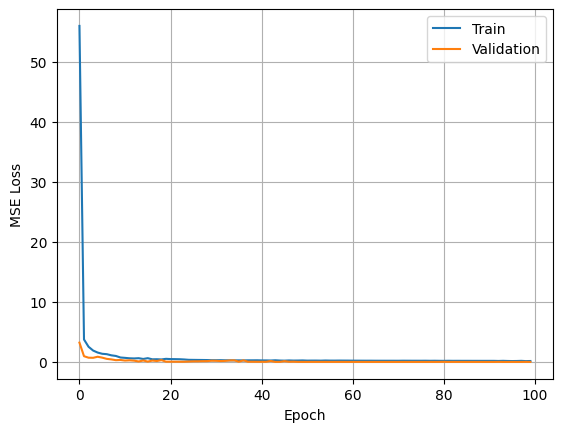

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def train_val_split(dataset, val_fraction=0.2):
    num_samples = len(dataset)
    num_val = int(num_samples * val_fraction)

    indices = torch.randperm(num_samples)

    val_indices = indices[:num_val]
    train_indices = indices[num_val:]

    train_data = [dataset[i] for i in train_indices]
    val_data = [dataset[i] for i in val_indices]

    return train_data, val_data


def train_one_epoch(model, train_data, optimizer, loss_fn, cutoff):
    model.train()

    total_loss = 0.0

    for sample in train_data:
        positions = sample["positions"]
        true_energy = sample["energy"]

        pred_energy = model(positions, cutoff)

        loss = loss_fn(pred_energy, true_energy)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    mean_loss = total_loss / len(train_data)

    return mean_loss


def evaluate(model, val_data, loss_fn, cutoff):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for sample in val_data:
            positions = sample["positions"]
            true_energy = sample["energy"]

            pred_energy = model(positions, cutoff)

            loss = loss_fn(pred_energy, true_energy)

            total_loss += loss.item()

    mean_loss = total_loss / len(val_data)

    return mean_loss


# Preparación

train_data, val_data = train_val_split(
    dataset,
    val_fraction=0.2
)

model = LJGraphNetwork(hidden_dim=64)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

num_epochs = 100
cutoff = 2.5

train_losses = []
val_losses = []


# Entrenamiento

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model,
        train_data,
        optimizer,
        loss_fn,
        cutoff
    )

    val_loss = evaluate(
        model,
        val_data,
        loss_fn,
        cutoff
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


# Plot de pérdidas

plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

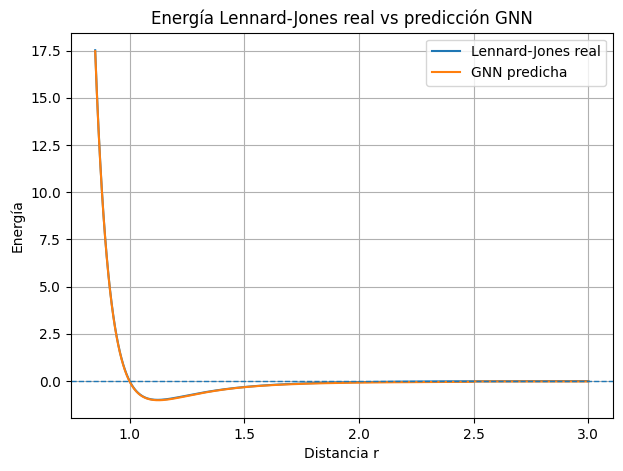

In [17]:
import torch
import matplotlib.pyplot as plt


def lj_pair_energy(r, epsilon=1.0, sigma=1.0):
    sr6 = (sigma / r)**6
    return 4 * epsilon * (sr6**2 - sr6)


r_values = torch.linspace(0.85, 3.0, 300)

true_energies = []
pred_energies = []

model.eval()

with torch.no_grad():
    for r in r_values:
        positions = torch.tensor([
            [0.0, 0.0, 0.0],
            [r.item(), 0.0, 0.0]
        ])

        true_E = lj_pair_energy(r)

        pred_E = model(
            positions,
            cutoff=2.5
        )

        true_energies.append(true_E.item())
        pred_energies.append(pred_E.item())


plt.figure(figsize=(7, 5))
plt.plot(r_values, true_energies, label="Lennard-Jones real")
plt.plot(r_values, pred_energies, label="GNN predicha")
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Distancia r")
plt.ylabel("Energía")
plt.title("Energía Lennard-Jones real vs predicción GNN")
plt.legend()
plt.grid(True)
plt.show()

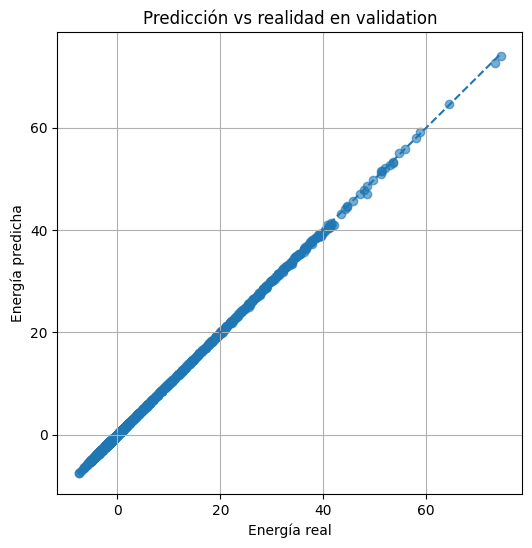

In [46]:
true_vals = []
pred_vals = []

model.eval()

with torch.no_grad():
    for sample in val_data:
        positions = sample["positions"]
        true_E = sample["energy"].reshape(())

        pred_E = model(
            positions,
            cutoff=2.5
        )

        true_vals.append(true_E.item())
        pred_vals.append(pred_E.item())


plt.figure(figsize=(6, 6))
plt.scatter(true_vals, pred_vals, alpha=0.6)

min_E = min(min(true_vals), min(pred_vals))
max_E = max(max(true_vals), max(pred_vals))

plt.plot([min_E, max_E], [min_E, max_E], linestyle="--")

plt.xlabel("Energía real")
plt.ylabel("Energía predicha")
plt.title("Predicción vs realidad en validation")
plt.grid(True)
plt.show()

In [58]:
import torch
import matplotlib.pyplot as plt

# 1. Energía Lennard-Jones real

def lennard_jones_energy(
    positions,
    epsilon=1.0,
    sigma=1.0,
    cutoff=None
):
    """
    Calcula la energía total Lennard-Jones para un conjunto de partículas.

    positions: tensor de shape (N, 2) o (N, 3)
    """

    N = positions.shape[0]
    energy = torch.tensor(0.0, dtype=positions.dtype, device=positions.device)

    for i in range(N):
        for j in range(i + 1, N):
            rij = positions[j] - positions[i]
            r = torch.norm(rij)

            if cutoff is not None and r > cutoff:
                continue

            sr6 = (sigma / r) ** 6
            energy += 4 * epsilon * (sr6**2 - sr6)

    return energy


# 2. Fuerzas reales usando autograd

def compute_real_lj_forces(
    positions,
    epsilon=1.0,
    sigma=1.0,
    cutoff=None
):
    """
    Fuerzas reales de Lennard-Jones:

        F = - grad(E)
    """

    positions = positions.clone().detach().requires_grad_(True)

    energy = lennard_jones_energy(
        positions,
        epsilon=epsilon,
        sigma=sigma,
        cutoff=cutoff
    )

    forces = -torch.autograd.grad(
        energy,
        positions,
        create_graph=False
    )[0]

    return energy.detach(), forces.detach()


# 3. Fuerzas predichas por la GNN usando autograd

def compute_gnn_forces(
    model,
    positions,
    cutoff=2.5
):
    """
    Fuerzas predichas por la GNN derivando la energía predicha:

        F_pred = - grad(E_pred)
    """

    model.eval()

    positions = positions.clone().detach().requires_grad_(True)

    pred_energy = model(positions, cutoff)

    pred_forces = -torch.autograd.grad(
        pred_energy,
        positions,
        create_graph=False
    )[0]

    return pred_energy.detach(), pred_forces.detach()


# 4. Función principal y plot

def analyze_molecule_forces(
    model,
    positions,
    cutoff=2.5,
    epsilon=1.0,
    sigma=1.0,
    scale=0.25,
    labels=True,
    xlim=None,
    ylim=None
):
    """
    Compara fuerzas reales LJ vs fuerzas predichas por la GNN.

    positions:
        lista o tensor con posiciones.
        Puede ser:
            [[x1, y1], [x2, y2], ...]
        o:
            [[x1, y1, z1], [x2, y2, z2], ...]

    scale:
        factor visual para las flechas.
    """

    positions = torch.tensor(
        positions,
        dtype=torch.float32
    )

    if positions.shape[1] not in [2, 3]:
        raise ValueError("positions debe tener shape (N, 2) o (N, 3).")

    pos_plot = positions[:, :2]

    real_energy, real_forces = compute_real_lj_forces(
        positions,
        epsilon=epsilon,
        sigma=sigma,
        cutoff=cutoff
    )

    pred_energy, pred_forces = compute_gnn_forces(
        model,
        positions,
        cutoff=cutoff
    )

    real_forces_plot = real_forces[:, :2]
    pred_forces_plot = pred_forces[:, :2]

    force_error = pred_forces - real_forces
    mae_force = force_error.abs().mean().item()
    rmse_force = torch.sqrt((force_error**2).mean()).item()

    energy_error = (pred_energy - real_energy).item()

    # Plot

    plt.figure(figsize=(7, 7))
        
    plt.scatter(
        pos_plot[:, 0],
        pos_plot[:, 1],
        s=80,
        label="Partículas"
    )

    N = positions.shape[0]

    for i in range(N):
        for j in range(i + 1, N):
            rij = positions[j] - positions[i]
            dist = torch.norm(rij)

            if dist < cutoff:
                plt.plot(
                    [pos_plot[i, 0].item(), pos_plot[j, 0].item()],
                    [pos_plot[i, 1].item(), pos_plot[j, 1].item()],
                    linestyle="--",
                    linewidth=1,
                    alpha=0.5
                )

    plt.quiver(
        pos_plot[:, 0],
        pos_plot[:, 1],
        real_forces_plot[:, 0],
        real_forces_plot[:, 1],
        angles="xy",
        scale_units="xy",
        scale=1 / scale,
        label="Fuerza LJ real",
        color="red"
    )

    plt.quiver(
        pos_plot[:, 0],
        pos_plot[:, 1],
        pred_forces_plot[:, 0],
        pred_forces_plot[:, 1],
        angles="xy",
        scale_units="xy",
        scale=1 / scale,
        label="Fuerza GNN predicha",
        color="blue"
    )

    if labels:
        for i in range(positions.shape[0]):
            plt.text(
                pos_plot[i, 0].item(),
                pos_plot[i, 1].item(),
                f" {i}",
                fontsize=12
            )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Fuerzas reales Lennard-Jones vs fuerzas predichas por GNN")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    if xlim is not None:
        plt.xlim(xlim)

    if ylim is not None:
        plt.ylim(ylim)

    plt.show()

    # Resultados numéricos

    print("====================================")
    print("ENERGÍA")
    print("====================================")
    print(f"E real LJ:      {real_energy.item(): .6f}")
    print(f"E predicha GNN: {pred_energy.item(): .6f}")
    print(f"Error energía: {energy_error: .6f}")

    print("\n====================================")
    print("FUERZAS")
    print("====================================")
    print(f"MAE fuerzas:   {mae_force: .6f}")
    print(f"RMSE fuerzas:  {rmse_force: .6f}")

    print("\nFuerzas reales LJ:")
    print(real_forces)

    print("\nFuerzas predichas GNN:")
    print(pred_forces)

    print("\nError de fuerzas:")
    print(force_error)

    return {
        "real_energy": real_energy,
        "pred_energy": pred_energy,
        "real_forces": real_forces,
        "pred_forces": pred_forces,
        "force_error": force_error,
        "mae_force": mae_force,
        "rmse_force": rmse_force
    }

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


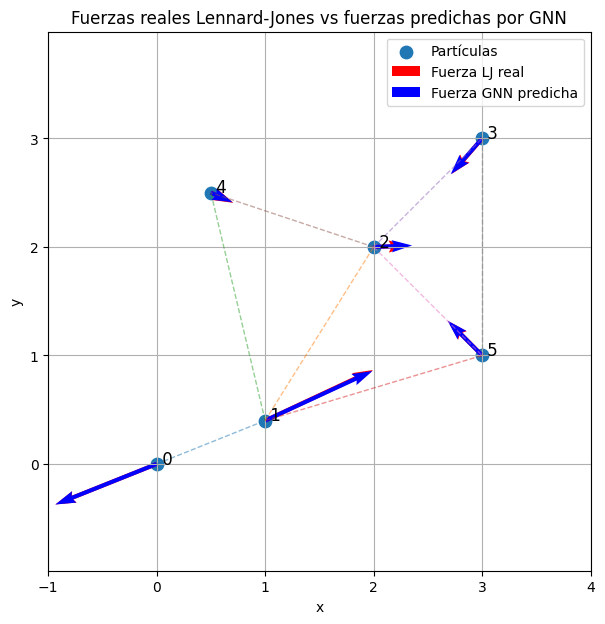

ENERGÍA
E real LJ:      -2.270508
E predicha GNN: -2.296808
Error energía: -0.026300

FUERZAS
MAE fuerzas:    0.027684
RMSE fuerzas:   0.039410

Fuerzas reales LJ:
tensor([[-3.7288, -1.4915],
        [ 3.9763,  1.8637],
        [ 1.3036,  0.0394],
        [-1.1250, -1.3066],
        [ 0.8286, -0.3726],
        [-1.2546,  1.2678]])

Fuerzas predichas GNN:
tensor([[-3.7355, -1.4942],
        [ 3.9553,  1.8264],
        [ 1.4180,  0.0551],
        [-1.1599, -1.3183],
        [ 0.7975, -0.3528],
        [-1.2753,  1.2839]])

Error de fuerzas:
tensor([[-0.0067, -0.0027],
        [-0.0210, -0.0373],
        [ 0.1145,  0.0157],
        [-0.0349, -0.0117],
        [-0.0311,  0.0198],
        [-0.0207,  0.0161]])


In [61]:
positions = [
    [0.0, 0.0],
    [1.0, 0.4],
    [2.0, 2.0],
    [3.0, 3.0],
    [0.5, 2.5],
    [3.0, 1.0]
]

results = analyze_molecule_forces(
    model=model,
    positions=positions,
    cutoff=2.5,
    epsilon=1.0,
    sigma=1.0,
    scale=0.25,
    xlim=(-1, 4),
    ylim=(-1, 4)
)